# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Loista Amanda Noviar
- **Email:** loistamnd1124@gmail.com
- **ID Dicoding:** loistamnd1124

## Menentukan Pertanyaan Bisnis

Berdasarkan dataset Bike Sharing, berikut merupakan pertanyaan bisnis yang ingin dijawab:

- Pertanyaan 1: Bagaimana kondisi cuaca dapat mempengaruhi jumlah penyewaan sepeda?
- Pertanyaan 2: Kapan jumlah penyewaan sepeda tertinggi berdasarkan waktu (jam)?

## Import Semua Packages/Library yang Digunakan

In [6]:
import numpy as mp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [7]:
df_day = pd.read_csv('data/day.csv')
df_hour = pd.read_csv('data/hour.csv')

In [8]:
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [9]:
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- dataset berhasil dimuat tanpa adanya kendala
- Terdapat dua jenis data dari dua dataset yang berbeda yaitu: data harian dan data per jam
- Dataset ini berisikan fitur penting seperti season(cuaca), temp(suhu), dan registered(jumlah penyewaan)

### Assessing Data

In [10]:
df_day.info()
df_day.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [11]:
df_day.duplicated().sum()

np.int64(0)

**Insight:**
- tidak ditemukan data yang hilang (missing values)
- tidak terdapat data duplikat
- sebagian besar tipe data sudah sesuai
- kolom tanggal masih perlu perbaikan agar dapat digunakan dalam anilisis berbasis waktu

In [12]:
df_hour.info()
df_hour.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [13]:
df_hour.duplicated().sum()

np.int64(0)

**Insight:**
- tidak ditemukan data yang hilang (missing values) pada dataset hour
- Dataset Hour memiliki jumlah data yang lebih banyak dibandingkan dataset day karena mencatat aktivitas penyewaan disetiap jam
- tidak terdapat data duplikat
- kolom tanggal masih perlu perbaikan agar dapat digunakan dalam anilisis berbasis waktu
- dataset hour memiliki tingkat granulatitas yang tinggi sehingga coco untuk analisis pola penggunaan berdasarkan waktu

### Cleaning Data

In [14]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

**Insight:**
- kolom tanggal sudah diperbaiki dengan cara dikonversi ke format data datetime
- Dataset sudah siap digunakan untuk Exploratory Data Analysis (EDA)

## Exploratory Data Analysis (EDA)

### Explore Dataset Day

In [15]:
df_day.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


**Insight:**
- Terdapat perbedaan variasi yang signifikan dalam jumlah penyewaan sepeda tiap harinya
- Faktor eksternal seperti cuaca dan suhu memungkinkan dalam mempengaruhi jumlah penyewa sepeda per harinya

###Explore Dataset Hour

In [16]:
df_hour.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


**Insight:**
- Dataset Hour menunjukan variasi jumlah penyewaan yang cukup tinggi dalam satu hari
- Nilai maksimum penyewaan per jam jauh lebih kecil dibandingkan dengan data Day, namun data hour memberikan detail pola penyewaan yang lebih spesifik
- Rata-rata penyewaan menunjukan adanya fluktuasi yang signifikan antar jam nya
- Hal ini mengindikasikan bahwa waktu(jam) merupakan salah satu faktor yang mempengaruhi intensitas penggunaan dan penyewaan sepeda

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana kondisi cuaca dapat mempengaruhi jumlah penyewaan sepeda?

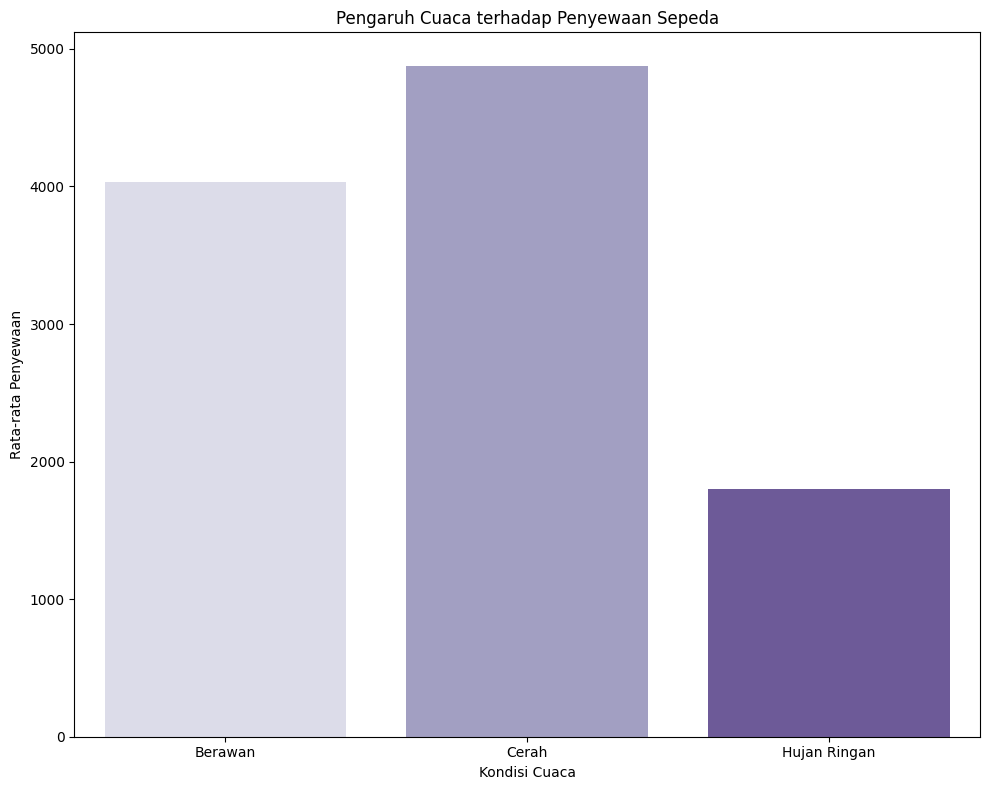

In [17]:
weather_map = {1:"Cerah", 2:"Berawan", 3:"Hujan Ringan"}
df_day['weather'] = df_day['weathersit'].map(weather_map)

weather_group = df_day.groupby('weather')['cnt'].mean().reset_index()

plt.figure(figsize=(10,8))
sns.barplot(
    data=weather_group,
    x='weather',
    y='cnt',
    palette='Purples'
)
plt.title("Pengaruh Cuaca terhadap Penyewaan Sepeda")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")
plt.tight_layout()
plt.show()

### Pertanyaan 2: Kapan jumlah penyewaan sepeda tertinggi berdasarkan waktu (jam)?

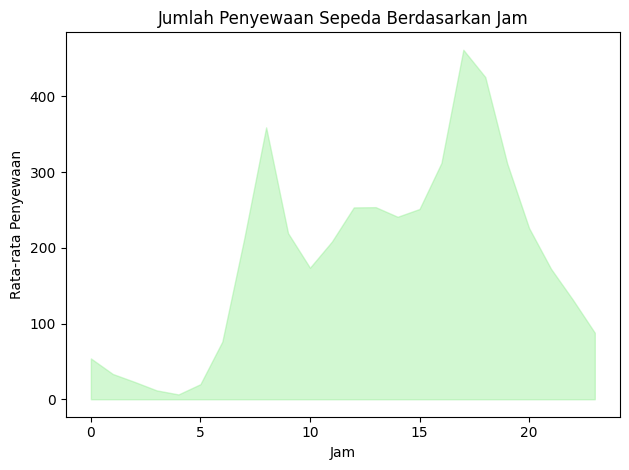

In [18]:
hour_group = df_hour.groupby('hr')['cnt'].mean().reset_index()

plt.fill_between(
    hour_group['hr'],
    hour_group['cnt'],
    color='#90EE90',
    alpha=0.4
)
plt.title("Jumlah Penyewaan Sepeda Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.tight_layout()
plt.show()

**Insight:**
- Kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda
- Cuaca Cerah menjadi cuaca dengan tingkat penyewaan tertinggi yang menunjukan pengguna lebih aktif pada kondisi lingkungan yang mendukung
- Jika dilihat dari waktu (jam), terdapat dua puncak utama penyewaan sepeda yaitu pagi dari pukul (7-9 pagi) dan sore pada pukul (16-18 sore)
- pola ini memberikan indikasi bahwa penyewa sepeda banyak menggunakan sepeda pada saat aktivitas mobilitas harian seperti berangkat kerja dan pulang kerja
- Sebaliknya, Kondisi cuaca yang buruk dan tidak mendukung juga diluar jam sibuk, jumlah pennyewa sepeda cenderung turun

## Analisis Lanjutan (Opsional)

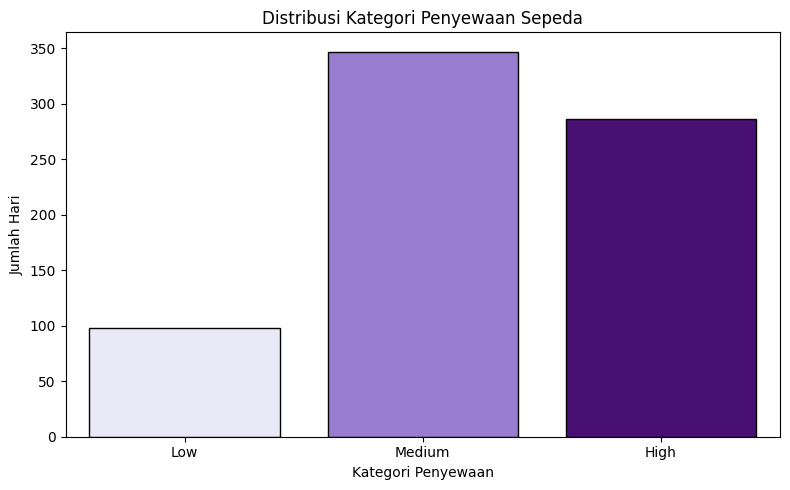

In [19]:
def kategori(cnt):
    if cnt < 2000:
        return "Low"
    elif cnt < 5000:
        return "Medium"
    else:
        return "High"

df_day['kategori'] = df_day['cnt'].apply(kategori)
kategori_group = df_day['kategori'].value_counts().reset_index()
kategori_group.columns = ['kategori', 'jumlah']

kategori_group['kategori'] = pd.Categorical(
    kategori_group['kategori'],
    categories=['Low', 'Medium', 'High'],
    ordered=True
)

kategori_group = kategori_group.sort_values('kategori')

plt.figure(figsize=(8,5))

sns.barplot(
    data=kategori_group,
    x='kategori',
    y='jumlah',
    palette=['#E6E6FA', '#9370DB', '#4B0082'],
    edgecolor='black'
)

plt.title("Distribusi Kategori Penyewaan Sepeda")
plt.xlabel("Kategori Penyewaan")
plt.ylabel("Jumlah Hari")
plt.tight_layout()
plt.show()

## Conclusion

- Conclution pertanyaan 1: Pengaruh kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. penyewaan sepeda tertinggi terjadi saat kondisi cuaca cerah, sedangkan pada kondisi cuaca buruk, jumlah penyewaan sepeda cenderung menurun. Hal ini menunjukan bahwa penguna penyewa sepeda lebih suka menggunakan sepeda ketika kondisi mendukung.

- Conclution pertanyaan 2: Waktu penyewaan sepeda tertinggi per harinya. penyewaan sepeda mencapai titik tertinggi pada jam sibuk yaitu saat pagi (pukul 7-9) dan sore (pukul 16-18). pola ini menunjukan bahwa sepeda banyak digunakan sebagai alat transportasi untuk beraktivitas berangkat dan pulang kerja.

In [22]:
df_day.to_csv('dashboard/main_data.csv', index=False)
df_hour.to_csv('dashboard/hour_data.csv', index=False)